# Data Preparation: Crash Reporting Completeness

Load and prepare Washington State crash data. Target: predict whether injury severity is reported (completeness proxy).

## Key Variables

**Target (R):** Reporting completeness
- R=1: Injury severity known → record is "complete"
- R=0: Unknown severity → missing data

**Sensitive Attributes:**
- VRU status (pedestrian/cyclist present)
- Jurisdiction type (rural/urban)

**Causal Structure (Collider):**
```
Severity → Reporting
    ↓       ↑
    └─ VRU─┘
```
Conditioning on R creates spurious correlation between severity and VRU status.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
sns.set_palette('colorblind')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported")

✓ Libraries imported


## Step 1: Load Raw Data

Load the Washington State Patrol crash summary data.

In [2]:
# Load data (adjust path to your data location)
# If data is in the repo root:
df_raw = pd.read_csv('../extension/WA_Crash_Summary_2025.csv')

print(f"Dataset loaded: {len(df_raw):,} crashes")
print(f"Date range: {df_raw['Collision Date'].min()} to {df_raw['Collision Date'].max()}")
print(f"\nColumns: {len(df_raw.columns)}")
df_raw.head()

Dataset loaded: 137,716 crashes
Date range: 1/1/25 0:00 to 9/9/25 9:57

Columns: 24


,Collision Report Number,Collision Date,County,City,Jurisdiction,Agency,Primary Trafficway,Secondary Trafficway,Block Number,Mile Post,...,Injury Severity,Object Struck,Damage Threshold Met,Hit and Run,Motor Vehicles Involved,Passengers Involved,Commercial Carrier Involved,School Bus Involved,Pedestrians Involved,Pedalcyclists Involved
0,EF52829,1/1/25 0:00,King,Seattle,Miscellaneous Trafficway,Municipal/City Police,12200 AURORA AVE N,NaN,NaN,NaN,...,Unknown Injury Collision,NaN,Y,Y,2,N,N,N,0,0
1,EF57080,1/1/25 0:00,Pierce,Sumner,State Road,State Patrol,SR 167 NB,24TH,NaN,8.0,...,Minor Injury Collision,NaN,Y,Y,2,N,N,N,0,0
2,EF61588,1/1/25 0:00,Douglas,East Wenatchee,Miscellaneous Trafficway,County Sheriff,2980 NW EMPIRE AVE,NaN,.,NaN,...,Unknown Injury Collision,NaN,N,Y,2,N,N,N,0,0
3,EF61588,1/1/25 0:00,Douglas,East Wenatchee,Miscellaneous Trafficway,County Sheriff,2980 NW EMPIRE AVE,NaN,.,NaN,...,Unknown Injury Collision,NaN,Y,Y,2,N,N,N,0,0
4,EF67888,1/1/25 0:00,King,SeaTac,City Street,Municipal/City Police,MILITARY RD S,S 152 ST,15200,NaN,...,No Injury Collision,NaN,Y,Y,2,N,N,N,0,0


In [3]:
# Check data info
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137716 entries, 0 to 137715
Data columns (total 24 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Collision Report Number      137716 non-null  object 
 1   Collision Date               137716 non-null  object 
 2   County                       137716 non-null  object 
 3   City                         131943 non-null  object 
 4   Jurisdiction                 137716 non-null  object 
 5   Agency                       137716 non-null  object 
 6   Primary Trafficway           137716 non-null  object 
 7   Secondary Trafficway         123454 non-null  object 
 8   Block Number                 82215 non-null   object 
 9   Mile Post                    39155 non-null   float64
 10  School Zone                  137716 non-null  object 
 11  Intersection Related         137716 non-null  object 
 12  Weather Condition            137608 non-null  object 
 13 

## Target Variable: Reporting Completeness

Create binary target from Injury Severity field:
- 1 = Known severity
- 0 = Unknown severity


In [4]:
# Create working dataframe
df = df_raw.copy()

# Create binary target: R = 1 if injury definitive, 0 if unknown
df['injury_definitive'] = (~df['Injury Severity'].str.contains(
    'Unknown', case=False, na=False
)).astype(int)

print("Target Variable: injury_definitive")
print("="*50)
print(df['Injury Severity'].value_counts())
print("\nBinary encoding:")
print(df['injury_definitive'].value_counts())
print(f"\nCompleteness rate: {df['injury_definitive'].mean():.1%}")

Target Variable: injury_definitive
Injury Severity
No Injury Collision         93291
Minor Injury Collision      29970
Unknown Injury Collision    10474
Serious Injury Collision     3176
Fatal Collision               805
Name: count, dtype: int64

Binary encoding:
injury_definitive
1    127242
0     10474
Name: count, dtype: int64

Completeness rate: 92.4%


## Sensitive Attributes


In [5]:
# Sensitive Attribute 1: VRU Status
df['is_vru'] = (
    (df['Pedestrians Involved'] > 0) | 
    (df['Pedalcyclists Involved'] > 0)
).astype(int)

print("Sensitive Attribute 1: VRU Status")
print("="*50)
print(f"VRU crashes: {df['is_vru'].sum():,} ({df['is_vru'].mean()*100:.1f}%)")
print(f"Non-VRU crashes: {(~df['is_vru'].astype(bool)).sum():,} ({(~df['is_vru'].astype(bool)).mean()*100:.1f}%)")

print("\nBreakdown:")
print(f"  Pedestrian crashes: {(df['Pedestrians Involved'] > 0).sum():,}")
print(f"  Cyclist crashes: {(df['Pedalcyclists Involved'] > 0).sum():,}")

Sensitive Attribute 1: VRU Status
VRU crashes: 5,234 (3.8%)
Non-VRU crashes: 132,482 (96.2%)

Breakdown:
  Pedestrian crashes: 3,367
  Cyclist crashes: 1,877


In [6]:
# Sensitive Attribute 2: Jurisdiction Type
rural_jurisdictions = ['County Road', 'State Road', 'Miscellaneous Trafficway']
df['rural_jurisdiction'] = df['Jurisdiction'].isin(rural_jurisdictions).astype(int)

print("Sensitive Attribute 2: Jurisdiction Type")
print("="*50)
print(df['Jurisdiction'].value_counts())
print("\nBinary encoding:")
print(f"Rural: {df['rural_jurisdiction'].sum():,} ({df['rural_jurisdiction'].mean()*100:.1f}%)")
print(f"Urban: {(~df['rural_jurisdiction'].astype(bool)).sum():,} ({(~df['rural_jurisdiction'].astype(bool)).mean()*100:.1f}%)")

Sensitive Attribute 2: Jurisdiction Type
Jurisdiction
City Street                 67608
State Road                  44438
County Road                 16553
Miscellaneous Trafficway     9117
Name: count, dtype: int64

Binary encoding:
Rural: 70,108 (50.9%)
Urban: 67,608 (49.1%)


## Non-Sensitive Features


In [7]:
# Feature 1: Hit and Run
df['hit_and_run'] = (df['Hit and Run'] == 'Y').astype(int)

# Feature 2: Night Crash
df['night_crash'] = df['Lighting Condition'].str.contains(
    'Dark', case=False, na=False
).astype(int)

# Feature 3: Adverse Weather
df['adverse_weather'] = df['Weather Condition'].isin([
    'Raining', 'Fog or Smog or Smoke', 'Snow or Sleet'
]).astype(int)

# Feature 4: Intersection Related
df['intersection'] = (df['Intersection Related'] == 'Y').astype(int)

# Feature 5: Multiple Vehicles
df['multiple_vehicles'] = (df['Motor Vehicles Involved'] > 1).astype(int)

print("Non-Sensitive Features Created")
print("="*50)
feature_stats = pd.DataFrame({
    'Feature': ['hit_and_run', 'night_crash', 'adverse_weather', 'intersection', 'multiple_vehicles'],
    'Prevalence': [
        df['hit_and_run'].mean(),
        df['night_crash'].mean(),
        df['adverse_weather'].mean(),
        df['intersection'].mean(),
        df['multiple_vehicles'].mean()
    ]
})
feature_stats['Prevalence'] = feature_stats['Prevalence'].apply(lambda x: f"{x*100:.1f}%")
print(feature_stats.to_string(index=False))

Non-Sensitive Features Created
          Feature Prevalence
      hit_and_run      20.1%
      night_crash      28.7%
  adverse_weather      14.8%
     intersection      34.8%
multiple_vehicles      75.9%


## Step 5: Key Finding - The Unexpected Pattern

Let's examine reporting completeness by group.

In [8]:
# Completeness by VRU status
print("REPORTING COMPLETENESS BY GROUP")
print("="*70)
print("\nBy VRU Status:")
vru_completeness = df.groupby('is_vru')['injury_definitive'].agg([
    ('Completeness_Rate', 'mean'),
    ('Count', 'count')
])
vru_completeness.index = ['Non-VRU', 'VRU']
vru_completeness['Completeness_Rate'] = vru_completeness['Completeness_Rate'].apply(lambda x: f"{x*100:.1f}%")
print(vru_completeness)

print("\nBy Jurisdiction:")
juris_completeness = df.groupby('rural_jurisdiction')['injury_definitive'].agg([
    ('Completeness_Rate', 'mean'),
    ('Count', 'count')
])
juris_completeness.index = ['Urban', 'Rural']
juris_completeness['Completeness_Rate'] = juris_completeness['Completeness_Rate'].apply(lambda x: f"{x*100:.1f}%")
print(juris_completeness)

REPORTING COMPLETENESS BY GROUP

By VRU Status:
        Completeness_Rate   Count
Non-VRU             92.2%  132482
VRU                 98.2%    5234

By Jurisdiction:
      Completeness_Rate  Count
Urban             92.2%  67608
Rural             92.6%  70108


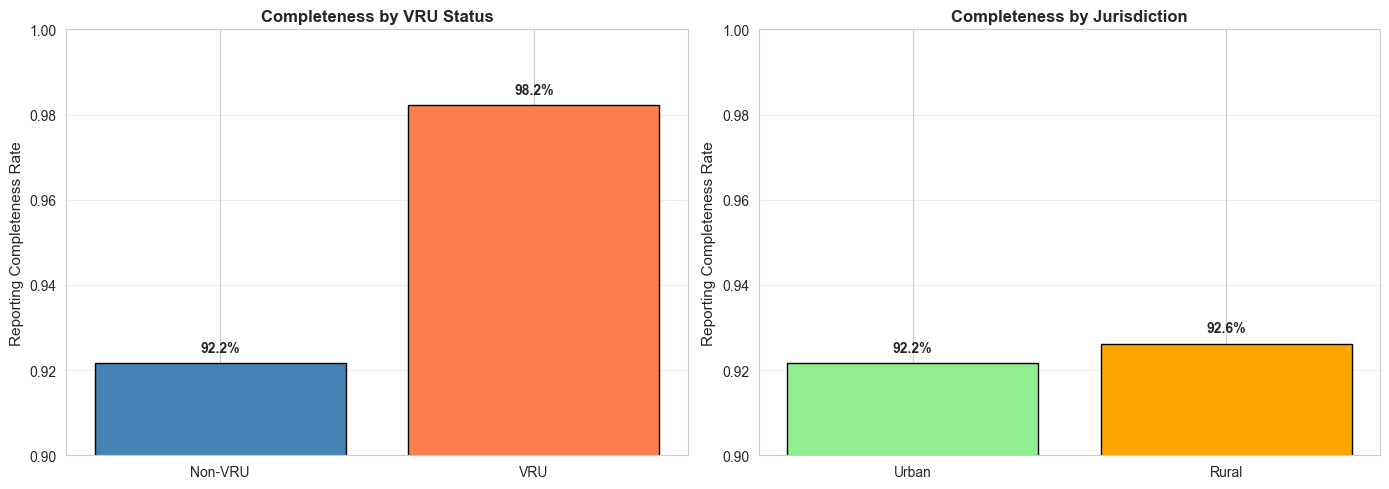


⚠️ KEY FINDING: VRU crashes have HIGHER completeness than non-VRU!
This represents INVERSE selection bias - will be verified formally with FVGM.


In [9]:
# Visualize the finding
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: VRU completeness
vru_rates = df.groupby('is_vru')['injury_definitive'].mean()
bars1 = axes[0].bar(['Non-VRU', 'VRU'], vru_rates, color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_ylabel('Reporting Completeness Rate', fontsize=11)
axes[0].set_title('Completeness by VRU Status', fontsize=12, fontweight='bold')
axes[0].set_ylim([0.9, 1.0])
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.002,
                f'{height:.1%}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Jurisdiction completeness
juris_rates = df.groupby('rural_jurisdiction')['injury_definitive'].mean()
bars2 = axes[1].bar(['Urban', 'Rural'], juris_rates, color=['lightgreen', 'orange'], edgecolor='black')
axes[1].set_ylabel('Reporting Completeness Rate', fontsize=11)
axes[1].set_title('Completeness by Jurisdiction', fontsize=12, fontweight='bold')
axes[1].set_ylim([0.9, 1.0])
axes[1].grid(axis='y', alpha=0.3)

for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.002,
                f'{height:.1%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('preliminary_completeness_rates.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n⚠️ KEY FINDING: VRU crashes have HIGHER completeness than non-VRU!")
print("This represents INVERSE selection bias - will be verified formally with FVGM.")

## Step 6: Prepare Clean Dataset

Select features, remove missing data, and create stratified sample.

In [10]:
# Select all features
feature_columns = [
    # Sensitive
    'is_vru', 'rural_jurisdiction',
    # Non-sensitive
    'hit_and_run', 'night_crash', 'adverse_weather',
    'intersection', 'multiple_vehicles',
    # Target
    'injury_definitive'
]

df_clean = df[feature_columns].dropna()

print(f"After removing missing data: {len(df_clean):,} crashes")
print(f"Dropped: {len(df) - len(df_clean):,} rows ({(len(df) - len(df_clean))/len(df)*100:.2f}%)")

After removing missing data: 137,716 crashes
Dropped: 0 rows (0.00%)


In [11]:
# Create stratified sample (15,000 crashes)
# Stratify by VRU status and injury definitive to ensure balanced representation

SAMPLE_SIZE = 15000

if len(df_clean) > SAMPLE_SIZE:
    df_sample, _ = train_test_split(
        df_clean,
        train_size=SAMPLE_SIZE,
        stratify=df_clean[['is_vru', 'injury_definitive']],
        random_state=42
    )
    print(f"✓ Stratified sample created: {len(df_sample):,} crashes")
else:
    df_sample = df_clean
    print(f"✓ Using full dataset: {len(df_sample):,} crashes")

# Verify stratification worked
print(f"\nSample composition:")
print(f"  VRU: {df_sample['is_vru'].sum():,} ({df_sample['is_vru'].mean()*100:.1f}%)")
print(f"  Definitive: {df_sample['injury_definitive'].sum():,} ({df_sample['injury_definitive'].mean()*100:.1f}%)")

✓ Stratified sample created: 15,000 crashes

Sample composition:
  VRU: 570 (3.8%)
  Definitive: 13,859 (92.4%)


## Step 7: Cross-Tabulation Analysis

Examine the 4 compound groups (VRU × Jurisdiction)

In [12]:
# Create compound groups
df_sample['compound_group'] = (
    df_sample['is_vru'].map({0: 'Non-VRU', 1: 'VRU'}) + ' × ' +
    df_sample['rural_jurisdiction'].map({0: 'Urban', 1: 'Rural'})
)

print("COMPOUND GROUPS (VRU × Jurisdiction)")
print("="*70)

# Crosstab: counts
crosstab_counts = pd.crosstab(
    df_sample['is_vru'].map({0: 'Non-VRU', 1: 'VRU'}),
    df_sample['rural_jurisdiction'].map({0: 'Urban', 1: 'Rural'}),
    margins=True
)
print("\nGroup Counts:")
print(crosstab_counts)

# Crosstab: completeness rates
crosstab_rates = pd.crosstab(
    df_sample['is_vru'].map({0: 'Non-VRU', 1: 'VRU'}),
    df_sample['rural_jurisdiction'].map({0: 'Urban', 1: 'Rural'}),
    df_sample['injury_definitive'],
    aggfunc='mean'
)
print("\nCompleteness Rates by Compound Group:")
print(crosstab_rates.applymap(lambda x: f"{x*100:.1f}%"))

COMPOUND GROUPS (VRU × Jurisdiction)

Group Counts:
rural_jurisdiction  Rural  Urban    All
is_vru                                 
Non-VRU              7513   6917  14430
VRU                   140    430    570
All                  7653   7347  15000

Completeness Rates by Compound Group:
rural_jurisdiction  Rural  Urban
is_vru                          
Non-VRU             92.4%  91.9%
VRU                 99.3%  97.9%


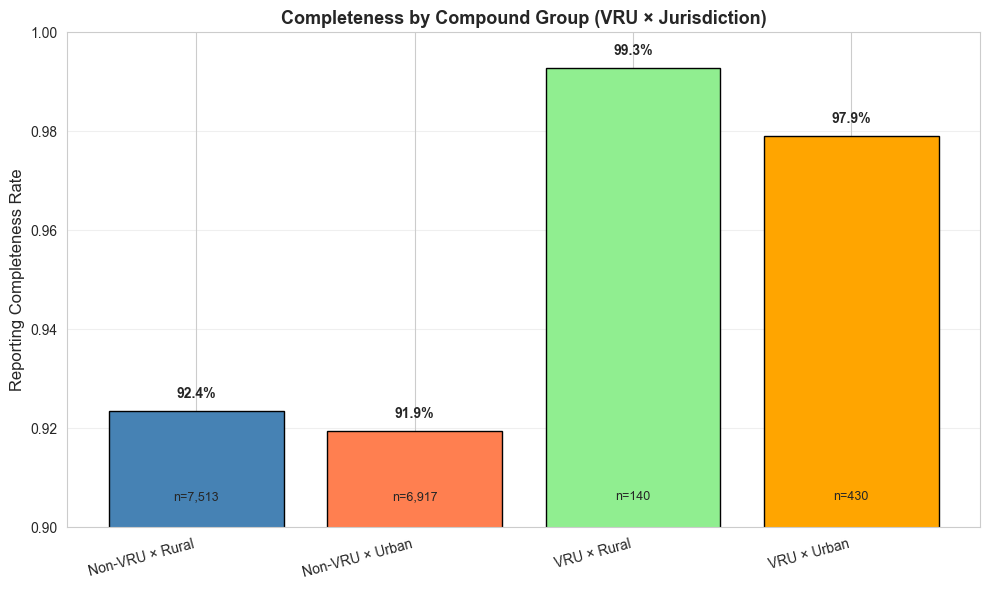

In [13]:
# Visualize compound groups
compound_stats = df_sample.groupby('compound_group')['injury_definitive'].agg([
    ('Completeness', 'mean'),
    ('Count', 'count')
]).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(compound_stats)), compound_stats['Completeness'], 
              color=['steelblue', 'coral', 'lightgreen', 'orange'], edgecolor='black')
ax.set_xticks(range(len(compound_stats)))
ax.set_xticklabels(compound_stats['compound_group'], rotation=15, ha='right')
ax.set_ylabel('Reporting Completeness Rate', fontsize=12)
ax.set_title('Completeness by Compound Group (VRU × Jurisdiction)', fontsize=13, fontweight='bold')
ax.set_ylim([0.9, 1.0])
ax.grid(axis='y', alpha=0.3)

# Add value labels and counts
for i, (bar, row) in enumerate(zip(bars, compound_stats.itertuples())):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.002,
            f'{height:.1%}', ha='center', va='bottom', fontweight='bold')
    ax.text(bar.get_x() + bar.get_width()/2., 0.905,
            f'n={row.Count:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('compound_group_completeness.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 8: Save Processed Data

In [14]:
# Save to experiments/vru_extension directory
output_dir = '../extension/'
import os
os.makedirs(output_dir, exist_ok=True)

output_file = os.path.join(output_dir, 'wa_vru_data_quality.csv')
df_sample.to_csv(output_file, index=False)

print(f"✓ Data saved to: {output_file}")
print(f"\nFinal dataset: {len(df_sample):,} crashes")
print(f"  VRU crashes: {df_sample['is_vru'].sum():,}")
print(f"  Features: {len(feature_columns)-1} (+ 1 target)")

✓ Data saved to: ../extension/wa_vru_data_quality.csv

Final dataset: 15,000 crashes
  VRU crashes: 570
  Features: 7 (+ 1 target)


In [15]:
# Save summary statistics
import json

summary_stats = {
    'total_crashes': int(len(df_sample)),
    'vru_crashes': int(df_sample['is_vru'].sum()),
    'vru_rate': float(df_sample['is_vru'].mean()),
    'completeness_rate': float(df_sample['injury_definitive'].mean()),
    'completeness_vru': float(df_sample[df_sample['is_vru']==1]['injury_definitive'].mean()),
    'completeness_non_vru': float(df_sample[df_sample['is_vru']==0]['injury_definitive'].mean()),
    'rural_rate': float(df_sample['rural_jurisdiction'].mean())
}

summary_file = os.path.join(output_dir, 'data_summary.json')
with open(summary_file, 'w') as f:
    json.dump(summary_stats, f, indent=2)

print(f"✓ Summary statistics saved to: {summary_file}")
print("\nSummary:")
print(json.dumps(summary_stats, indent=2))

✓ Summary statistics saved to: ../extension/data_summary.json

Summary:
{
  "total_crashes": 15000,
  "vru_crashes": 570,
  "vru_rate": 0.038,
  "completeness_rate": 0.9239333333333334,
  "completeness_vru": 0.9824561403508771,
  "completeness_non_vru": 0.9216216216216216,
  "rural_rate": 0.5102
}


## Summary

**What we created:**
1. ✓ Binary target: `injury_definitive` (reporting completeness)
2. ✓ Sensitive attributes: `is_vru`, `rural_jurisdiction`
3. ✓ Non-sensitive features: crash characteristics (5 features)
4. ✓ Clean dataset: 15,000 crashes

**Key finding:**
- VRU crashes have HIGHER completeness (98.2%) than non-VRU (92.2%)
- This represents inverse selection bias
- Will verify formally with FVGM in next notebook

**Next step:** Notebook 2 - Demonstrate Collider Bias